In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

In [2]:
def read_csv(file_path: str) -> pd.DataFrame:
    """Reads a CSV file and returns a DataFrame.
    
    Args:
        file_path (str): Path to the CSV file.
    """
    return pd.read_csv(file_path)

In [7]:
# Read in processed dataset
processed_mintlify_df = read_csv("../../../ProcessedDatasets/processed_mintlify_dataset_2026-01-13.csv")

# Read in judge output
judge_output_df = read_csv("../../JudgeResults/evaluation_results_2026-01-13.csv")

# Combine processed dataset with judge output
combined_df = pd.concat([processed_mintlify_df.reset_index(drop=True), judge_output_df.reset_index(drop=True)], axis=1)

# Count the length of each query
combined_df['query_length'] = combined_df['query'].apply(lambda x: len(str(x).split()))

In [8]:
combined_df.head()

,timestamp,query,response,sources,reason,score,decision,answer_correct,has_error,error_message,query_length
0,2025-12-11T20:27:26.018Z,which users can view traces?,"Based on the search results, trace visibility ...","[{""title"":""Support"",""url"":""models/support""},{""...",The generated answer makes specific claims abo...,1.0,incorrect,False,False,NaN,5
1,2025-12-11T20:23:16.628Z,view traces,To view traces in Weave:\n\n1. Navigate to you...,"[{""title"":""Supported W&B Server releases"",""url...",The generated answer provides practical inform...,2.0,incorrect,False,False,NaN,2
2,2025-12-11T20:20:00.866Z,How to view weave traces in a models workspace...,"Based on the search results, I found detailed ...","[{""title"":""Weave and Models integration demo"",...",The generated answer provides specific technic...,2.0,incorrect,False,False,NaN,13
3,2025-12-11T20:18:27.595Z,weave models integration,"Based on the search results, **Weave integrate...","[{""title"":""Evaluate models with W&B Weave and ...",The generated answer provides a reasonable ove...,2.0,incorrect,False,False,NaN,3
4,2025-12-11T19:58:37.502Z,how to migrate all the runs/experiments from p...,"Based on the search results, I can help you wi...","[{""title"":""Group runs into experiments"",""url"":...",The generated answer provides a clear step-by-...,3.0,correct,True,False,NaN,13


### Make Pie Charts of Evaluation Results

In [21]:
def calculate_score_distribution(judge_output_df: pd.DataFrame) -> list[float]:
    """Calculates the distribution of scores in the judge output DataFrame.
    
    Args:
        judge_output_df (pd.DataFrame): DataFrame containing judge outputs with a 'score' column.
    """
    print("Calculating score distribution...")
    score_percent_3 =  (judge_output_df[judge_output_df['score'] == 3].shape[0] / judge_output_df.shape[0]) * 100
    score_percent_2 =  (judge_output_df[judge_output_df['score'] == 2].shape[0] / judge_output_df.shape[0]) * 100
    score_percent_1 =  (judge_output_df[judge_output_df['score'] == 1].shape[0] / judge_output_df.shape[0]) * 100

    return [score_percent_3, score_percent_2, score_percent_1]

In [22]:
# Calculate and plot score distribution
score_distribution = calculate_score_distribution(judge_output_df)

# Find the time range of the dataset
min_timestamp = combined_df["timestamp"].min()
max_timestamp = combined_df["timestamp"].max()

Calculating score distribution...


In [ ]:
# def pie_chart(score_distribution: list[float], timerange: tuple[datetime.datetime, datetime.datetime]) -> None:
#     """Generates a pie chart for the score distribution.
    
#     Args:
#         score_distribution (list[float]): List containing percentage of scores [score 3, score 2, score 1].
#     """
#     print("Generating score distribution pie chart...")
#     labels = ['Score 3', 'Score 2', 'Score 1']
#     colors = sns.color_palette('pastel')[0:3]
#     plt.pie(score_distribution, labels=labels, colors=colors, explode=(0.1, 0, 0), autopct='%1.1f%%')
#     plt.axis('equal')
#     plt.title(f'Score Distribution from {timerange[0].strftime("%Y-%m-%d")} to {timerange[1].strftime("%Y-%m-%d")}')
#     plt.show()

def pie_chart(score_distribution: list[float], timerange: tuple[datetime.datetime, datetime.datetime]) -> None:
    """Generates a pie chart for the score distribution.
    
    Args:
        score_distribution (list[float]): List containing percentage of scores [score 3, score 2, score 1].
    """
    print("Generating score distribution pie chart...")
    labels = ['Score 3', 'Score 2', 'Score 1']
    score_definition = ['Score 3: Excellent', 'Score 2: Good', 'Score 1: Poor'] 
    
    fig, ax = plt.subplots(figsize=(6, 3), subplot_kw=dict(aspect="equal"))
    colors = sns.color_palette('rainbow')[0:3]
    wedges, texts, autotexts  = ax.pie(score_distribution, labels=labels, colors=colors, autopct='%1.1f%%')
    ax.legend(wedges, score_definition,
          title="Score definitions",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))
    ax.set_title(f'Score Distribution from {timerange[0].strftime("%Y-%m-%d")} to {timerange[1].strftime("%Y-%m-%d")}', loc='center')
    plt.show()

Generating score distribution pie chart...


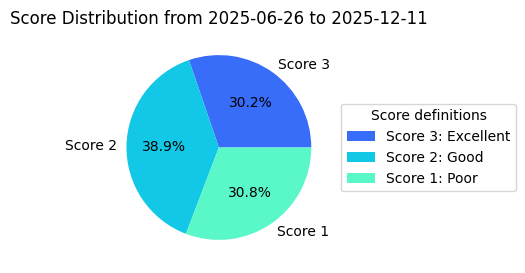

In [56]:
# Generate pie chart for score distribution
pie_chart(score_distribution, timerange=(min_timestamp, max_timestamp))